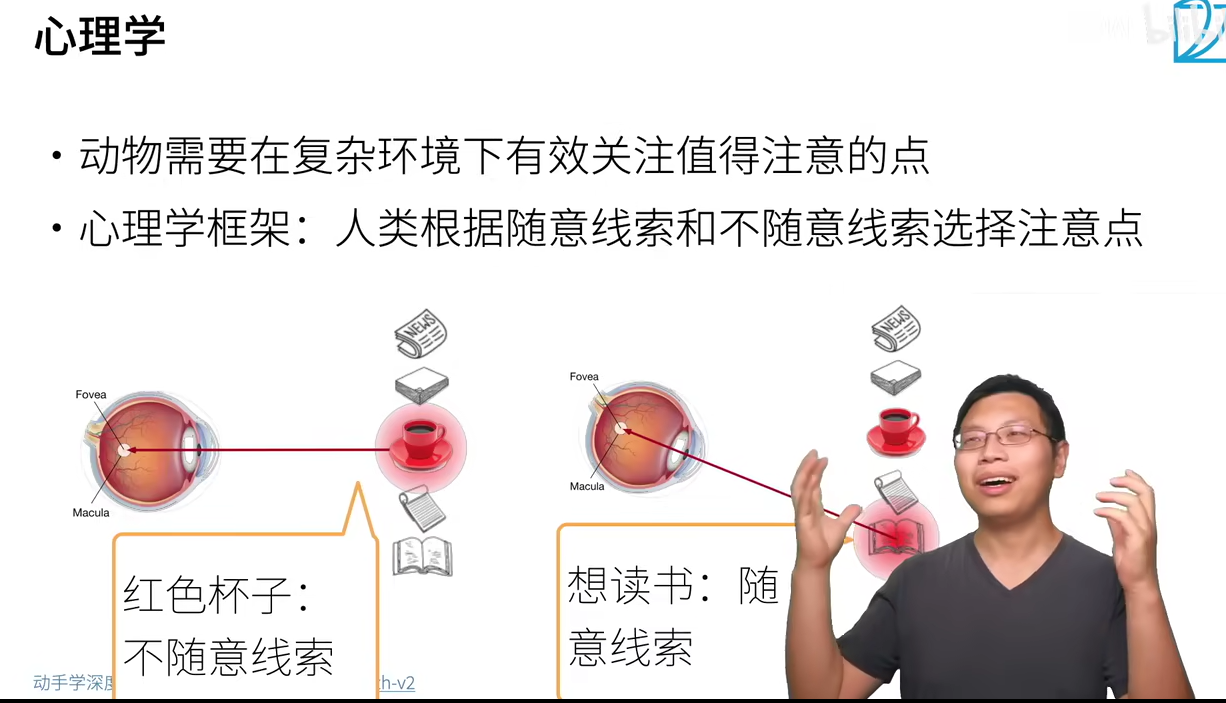
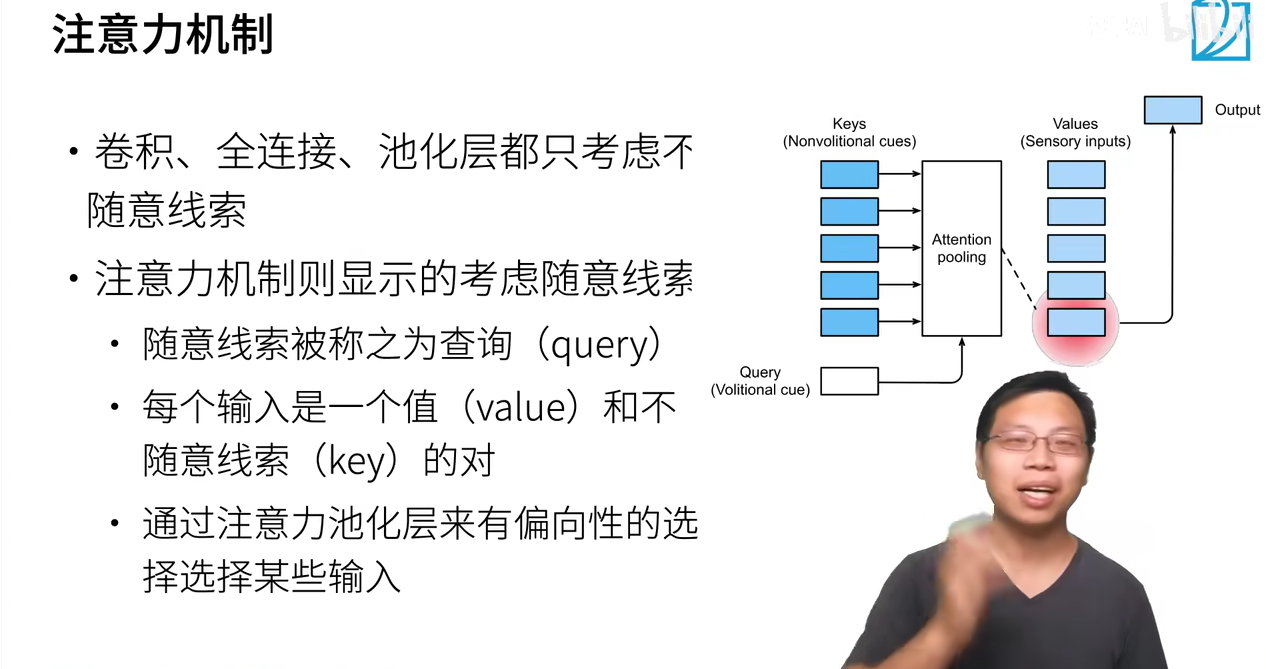

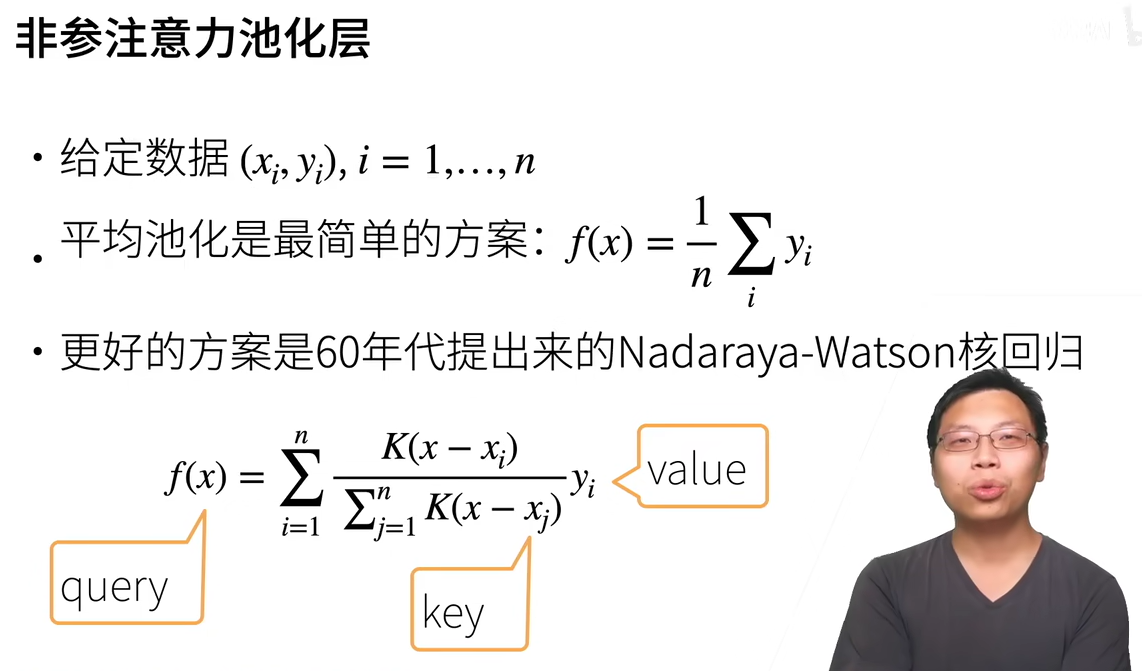
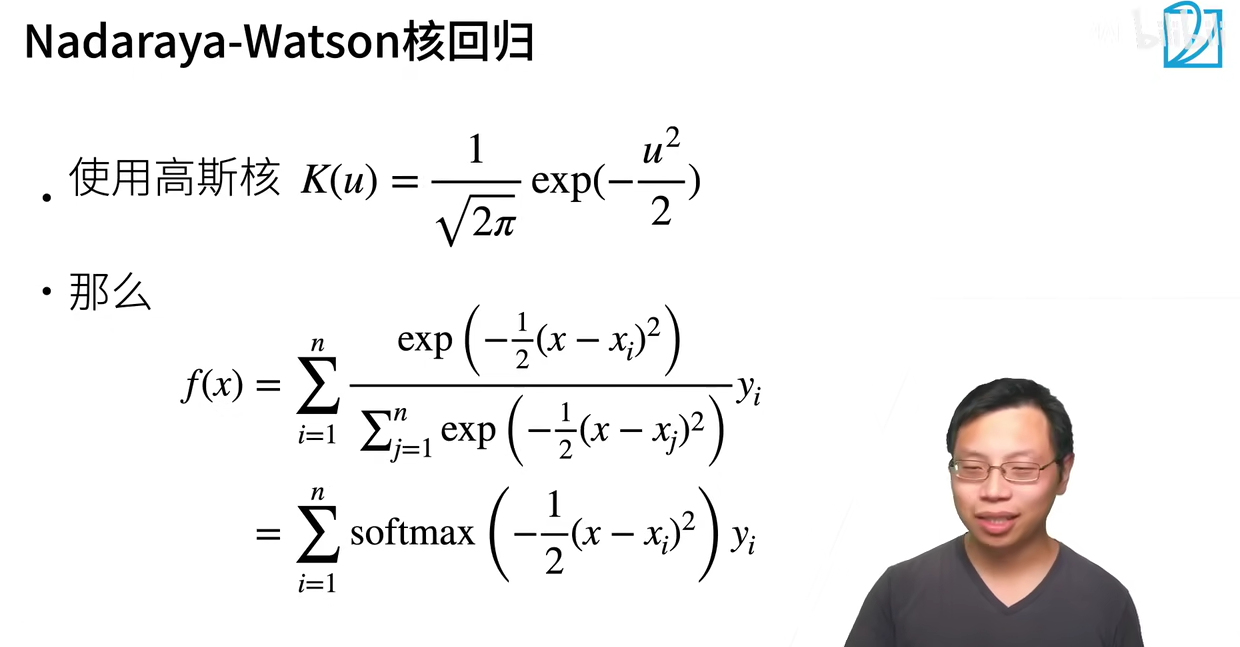

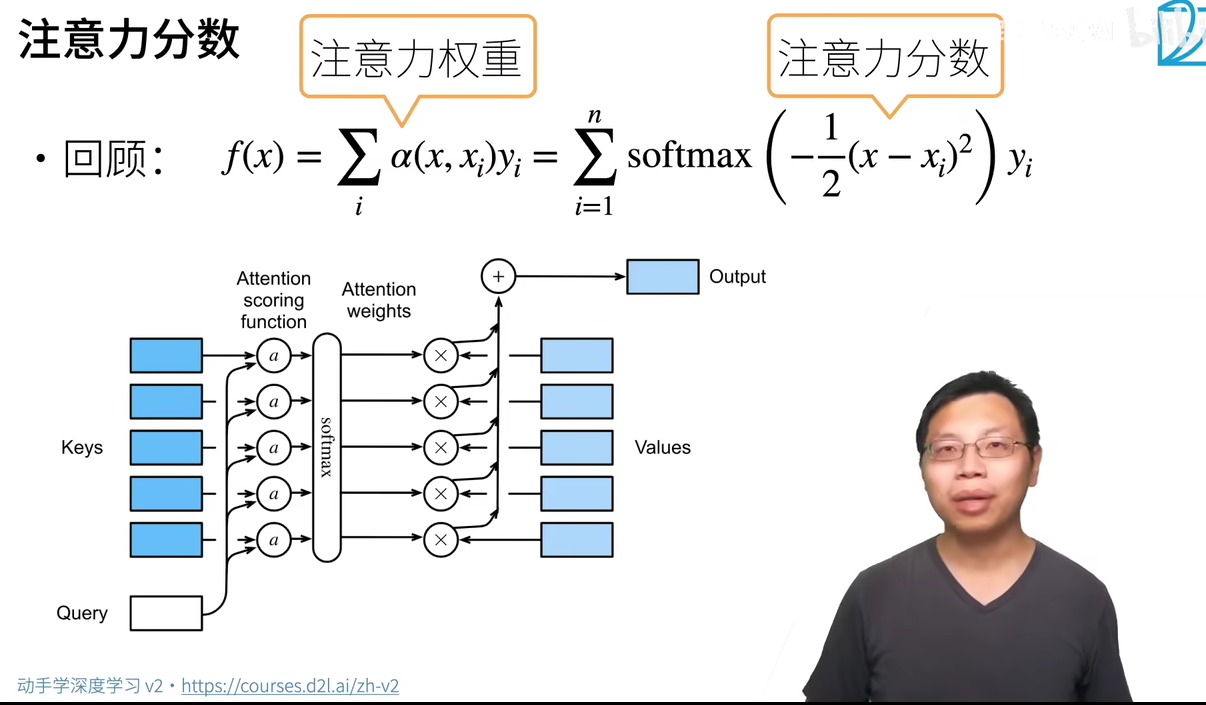
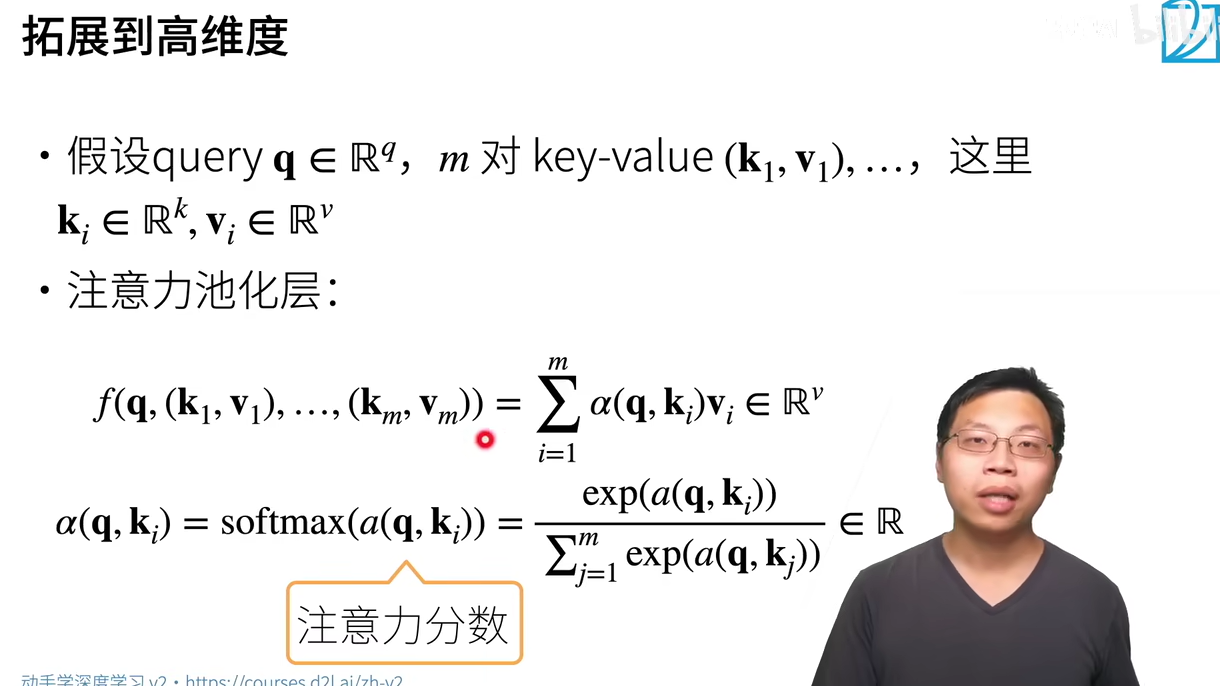
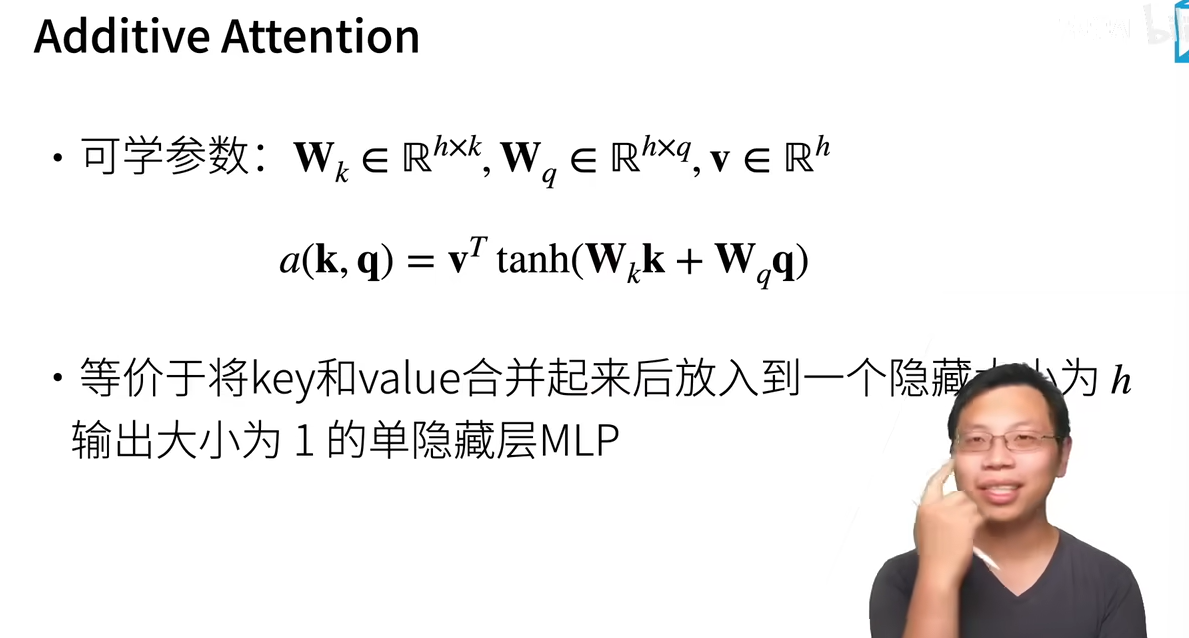

In [11]:
import torch
import torch.nn as nn
import math

def sequence_mask(X, valid_len, value=0):
    """把超出有效长度的位置填为 value"""
    maxlen = X.size(1)
    mask = torch.arange(maxlen, dtype=torch.float32, device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

def masked_softmax(X, valid_lens):
    """在最后一个轴上做带遮罩的 softmax"""
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    
    shape = X.shape
    if valid_lens.dim() == 1:
        valid_lens = torch.repeat_interleave(valid_lens, shape[1])
    else:
        valid_lens = valid_lens.reshape(-1)
        
    X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e9)
    return nn.functional.softmax(X.reshape(shape), dim=-1)


class DotProductAttention(nn.Module):
    """缩放点积注意力"""
    def __init__(self, dropout=0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    # queries 的形状：(batch_size, 查询的个数, d)
    # keys 的形状：(batch_size, 键值对的个数, d)
    # values 的形状：(batch_size, 键值对的个数, 值的维度)
    # valid_lens 的形状：(batch_size,) 或 (batch_size, 查询的个数)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        
        # 1. 你的第一步：算相似度打分
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        
        # 2. 第二步：Mask + Softmax 算百分比权重
        self.attention_weights = masked_softmax(scores, valid_lens)
        
        # 3. 你的第三步：加权混合 values 特征
        return torch.bmm(self.dropout(self.attention_weights), values)


# ==================== 单元测试验证 ====================
# 模拟 2 句话，每句 1 个 query，每个 query 维度为 2
queries = torch.normal(0, 1, (2, 1, 2)) 
# 模拟 2 句话，每句 10 个 key-value 对，key 维度也是 2，value 维度是 4
keys = torch.ones((2, 10, 2))
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(2, 1, 1)
# 第 1 句话只看前 2 个 key，第 2 句话看前 6 个 key
valid_lens = torch.tensor([2, 6]) 

attention = DotProductAttention(dropout=0.5)
attention.eval()
output = attention(queries, keys, values, valid_lens)

print("=== 缩放点积注意力运行成功 ===")
print("输出特征形状 (output shape):", output.shape) # 应为 [2, 1, 4]
print("注意力权重形状 (weights shape):", attention.attention_weights.shape) # 应为 [2, 1, 10]
print("第 1 句话的注意力权重分布:\n", attention.attention_weights[0])
print("第 2 句话的注意力权重分布:\n", attention.attention_weights[1])

=== 缩放点积注意力运行成功 ===
输出特征形状 (output shape): torch.Size([2, 1, 4])
注意力权重形状 (weights shape): torch.Size([2, 1, 10])
第 1 句话的注意力权重分布:
 tensor([[0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]])
第 2 句话的注意力权重分布:
 tensor([[0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000, 0.0000,
         0.0000]])
